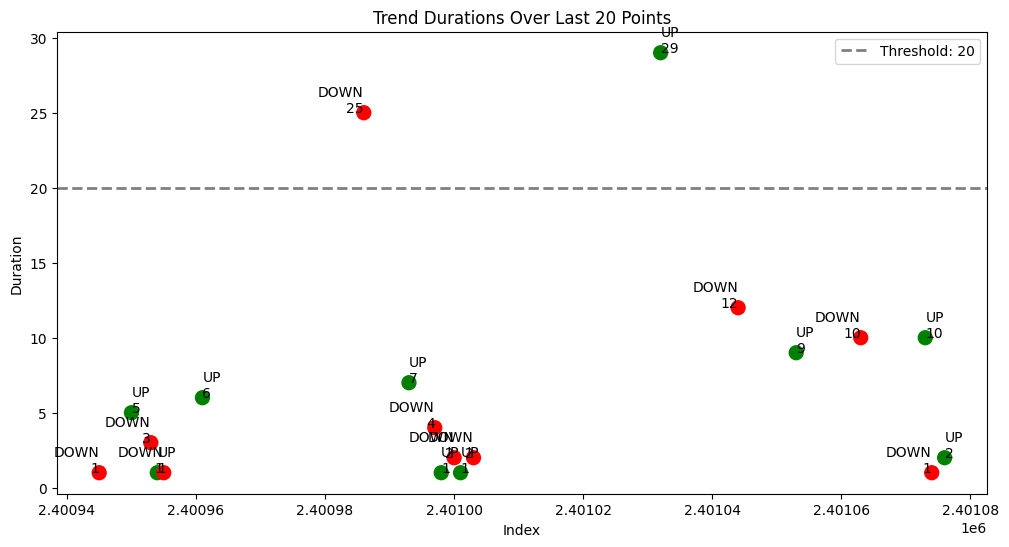

In [2]:
import feather
import pandas as pd
import talib
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
dataset_path = '/allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-1m-futures.feather'
dataframe = feather.read_dataframe(dataset_path)

# Calculate Triple Exponential Moving Average (TEMA) on closing prices
tema_period = 50
dataframe['tema'] = talib.TEMA(dataframe['close'], timeperiod=tema_period)

# Establish the trend direction
conditions = [
    dataframe['tema'] > dataframe['tema'].shift(1),
    dataframe['tema'] < dataframe['tema'].shift(1)
]
choices = ['DOWN', 'UP']
dataframe['trend'] = np.select(conditions, choices, default='STABLE')

# Identify trend change points
dataframe['trend_change'] = dataframe['trend'] != dataframe['trend'].shift(1)
dataframe['trend_change_point'] = dataframe['trend_change'] & (dataframe['trend'] != 'STABLE')

# Create a separate DataFrame for change points to avoid SettingWithCopyWarning
change_points = dataframe[dataframe['trend_change_point']].copy()
change_points['duration'] = change_points.index.to_series().diff().fillna(0)

# Format data for plotting
change_points = change_points.round({'tema': 2, 'volume': 2})
if 'date' in change_points.columns:
    change_points['date'] = change_points['date'].dt.strftime('%Y-%m-%d %H:%M')

# Prepare for visualization
plot_data = change_points.copy()
plot_data['previous_trend'] = plot_data['trend'].shift(1)
plot_data.dropna(subset=['duration'], inplace=True)

# Define parameters for the plot
plot_window = 20
plot_data = plot_data.tail(plot_window)

# Create the scatter plot
plt.figure(figsize=(12, 6))
trend_colors = {'UP': 'red', 'DOWN': 'green', 'STABLE': 'blue'}
plt.scatter(plot_data.index, plot_data['duration'], 
            c=plot_data['previous_trend'].map(trend_colors), 
            marker='o', s=100)

# Additional plot formatting
plt.axhline(y=20, color='gray', linestyle='--', linewidth=2, label='Threshold: 20')
plt.xlabel('Index')
plt.ylabel('Duration')
plt.title(f'Trend Durations Over Last {plot_window} Points')

# Annotate points
for idx, row in plot_data.iterrows():
    alignment = 'right' if row['trend'] == 'DOWN' else 'left'
    plt.text(idx, row['duration'], f"{row['trend']}\n{int(row['duration'])}", ha=alignment)

plt.legend()
plt.show()


In [42]:
import feather
import pandas as pd
import talib
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
dataset_path = '/allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-1m-futures.feather'
dataframe = feather.read_dataframe(dataset_path)

# Calculate Triple Exponential Moving Average (TEMA) on closing prices
tema_period = 50
dataframe['tema'] = talib.TEMA(dataframe['close'], timeperiod=tema_period)

# Establish the trend direction
conditions = [
    dataframe['tema'] > dataframe['tema'].shift(1),
    dataframe['tema'] < dataframe['tema'].shift(1)
]
choices = ['DOWN', 'UP']
dataframe['trend'] = np.select(conditions, choices, default='STABLE')

# Identify trend change points
dataframe['trend_change'] = dataframe['trend'] != dataframe['trend'].shift(1)
dataframe['trend_change_point'] = dataframe['trend_change'] & (dataframe['trend'] != 'STABLE')

# Create a separate DataFrame for change points to avoid SettingWithCopyWarning
change_points = dataframe[dataframe['trend_change_point']].copy()
change_points['duration'] = change_points.index.to_series().diff().fillna(0)

# Format data for plotting (this step is kept for possible later usage)
change_points = change_points.round({'tema': 2, 'volume': 2})
if 'date' in change_points.columns:
    change_points['date'] = change_points['date'].dt.strftime('%Y-%m-%d %H:%M')

# Calculate signed durations based on trend
change_points['signed_duration'] = change_points.apply(lambda row: row['duration'] if row['trend'] == 'UP' else -row['duration'], axis=1)

# Extracting the signed durations list
duration_list = change_points['signed_duration'].tolist()

# Optionally, print or use this list
print(duration_list)

duration_data = pd.DataFrame(duration_list, columns=['duration'])


[-0.0, 61.0, -1.0, 2.0, -2.0, 1.0, -4.0, 6.0, -1.0, 2.0, -2.0, 2.0, -1.0, 13.0, -4.0, 3.0, -1.0, 1.0, -2.0, 14.0, -1.0, 1.0, -5.0, 2.0, -1.0, 4.0, -12.0, 1.0, -3.0, 5.0, -15.0, 1.0, -1.0, 7.0, -1.0, 5.0, -1.0, 1.0, -1.0, 11.0, -13.0, 17.0, -1.0, 4.0, -24.0, 3.0, -6.0, 1.0, -1.0, 1.0, -3.0, 2.0, -3.0, 13.0, -1.0, 2.0, -1.0, 51.0, -20.0, 1.0, -1.0, 1.0, -1.0, 13.0, -4.0, 27.0, -4.0, 9.0, -3.0, 1.0, -4.0, 2.0, -3.0, 1.0, -4.0, 5.0, -2.0, 2.0, -4.0, 1.0, -1.0, 1.0, -3.0, 10.0, -6.0, 4.0, -35.0, 1.0, -7.0, 36.0, -15.0, 1.0, -5.0, 8.0, -3.0, 1.0, -1.0, 24.0, -35.0, 6.0, -10.0, 3.0, -18.0, 23.0, -1.0, 27.0, -26.0, 3.0, -13.0, 21.0, -35.0, 54.0, -7.0, 6.0, -23.0, 1.0, -1.0, 3.0, -2.0, 1.0, -10.0, 2.0, -2.0, 1.0, -1.0, 2.0, -4.0, 1.0, -1.0, 1.0, -5.0, 1.0, -1.0, 1.0, -1.0, 3.0, -1.0, 1.0, -9.0, 1.0, -1.0, 2.0, -7.0, 1.0, -6.0, 2.0, -2.0, 32.0, -1.0, 5.0, -27.0, 1.0, -1.0, 24.0, -29.0, 7.0, -29.0, 1.0, -7.0, 19.0, -1.0, 1.0, -4.0, 38.0, -1.0, 1.0, -15.0, 2.0, -4.0, 6.0, -1.0, 4.0, -5.0, 10.0, -2

In [43]:
# print nail
duration_data = duration_data[-50000:].reset_index(drop=True)

In [44]:
duration_data[-10:]

,duration
49990,-8.0
49991,1.0
49992,-13.0
49993,18.0
49994,-10.0
49995,4.0
49996,-14.0
49997,2.0
49998,-2.0
49999,20.0


In [36]:
import numpy as np
import os
import datetime
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import TensorBoard

# Load and prepare the duration data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(duration_data.values.reshape(-1, 1))  # Rescale data

# Function to create dataset suitable for classification
def create_dataset(data, step_size, prediction_window):
    X, y = [], []
    for i in range(len(data) - step_size - prediction_window):
        X.append(data[i:(i + step_size), 0])
        # Check if any value in the prediction window meets the condition
        y.append(np.any(data[i + step_size:i + step_size + prediction_window, 0] > 20) or
                 np.any(data[i + step_size:i + step_size + prediction_window, 0] < -20))
    return np.array(X), np.array(y).astype(int)

# Define parameters
step_size = 20
prediction_window = 4  # Looking ahead 4 steps
X, y = create_dataset(scaled_data, step_size, prediction_window)

# Split the data into training and validation sets
split_ratio = 0.8
split = int(X.shape[0] * split_ratio)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# Reshape input for LSTM [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], step_size, 1)
X_val = X_val.reshape(X_val.shape[0], step_size, 1)

# Setup TensorBoard for monitoring
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Construct the LSTM model for classification
model = Sequential([
    LSTM(50, input_shape=(step_size, 1), return_sequences=True),
    LSTM(50),
    Dense(1, activation='sigmoid')
])

# Compile the model for a binary classification problem
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val), callbacks=[tensorboard_callback])

# Function to predict if a large change is expected within the next prediction window
def predict_large_change(data):
    last_sequence = data[-step_size:].reshape(-1, 1)
    last_sequence_scaled = scaler.transform(last_sequence)  # Scale the data
    last_sequence_reshaped = last_sequence_scaled.reshape(1, step_size, 1)  # Reshape for the model
    predicted_prob = model.predict(last_sequence_reshaped)[0, 0]
    return predicted_prob

# Example: predict the likelihood of a large change in the next values
large_change_prob = predict_large_change(duration_data.values)
print("Probability of a large change:", large_change_prob)


KeyboardInterrupt: 

In [49]:
import numpy as np
import os
import datetime
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import TensorBoard

# Load and prepare the duration data
# Assuming duration_data is already loaded and available as a pandas DataFrame
data_values = duration_data.values.reshape(-1, 1)  # No rescaling applied

# Function to create dataset suitable for multi-class classification
def create_dataset(data, step_size, prediction_window):
    X, y = [], []
    for i in range(len(data) - step_size - prediction_window):
        X.append(data[i:(i + step_size), 0])
        future_segment = data[i + step_size:i + step_size + prediction_window, 0]
        if np.any(future_segment > 20):
            label = 0  # Values greater than 20
        elif np.any(future_segment < -20):
            label = 1  # Values less than -20
        else:
            label = 2  # Neither condition met
        y.append(label)
    return np.array(X), np.array(y)

# Define parameters
step_size = 20
prediction_window = 4  # Looking ahead 4 steps
X, y = create_dataset(data_values, step_size, prediction_window)

# Split the data into training and validation sets
split_ratio = 0.8
split = int(X.shape[0] * split_ratio)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# Reshape input for LSTM [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], step_size, 1)
X_val = X_val.reshape(X_val.shape[0], step_size, 1)

# Setup TensorBoard for monitoring
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Construct the LSTM model for multi-class classification with dropout
model = Sequential([
    LSTM(50, input_shape=(step_size, 1), return_sequences=True),
    Dropout(0.2),  # Dropout added after first LSTM layer
    LSTM(50),
    Dropout(0.2),  # Dropout added after second LSTM layer
    Dense(3, activation='softmax')
])

# Compile the model for a multi-class classification problem
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val), callbacks=[tensorboard_callback])

# Function to predict the class of large changes
def predict_change_category(data):
    last_sequence = data[-step_size:].reshape(1, step_size, 1)  # Adjust the reshaping here for prediction
    predicted_class = model.predict(last_sequence).argmax()
    return predicted_class

# Example: predict the class for the next values
change_category = predict_change_category(data_values)
categories = ['Greater than 20', 'Less than -20', 'Neither']
print("Predicted category for the next values:", categories[change_category])


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.6527 - loss: 0.8819 - val_accuracy: 0.6703 - val_loss: 0.8628
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6480 - loss: 0.8810 - val_accuracy: 0.6703 - val_loss: 0.8504
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.6502 - loss: 0.8748 - val_accuracy: 0.6703 - val_loss: 0.8554
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6497 - loss: 0.8765 - val_accuracy: 0.6703 - val_loss: 0.8509
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6481 - loss: 0.8772 - val_accuracy: 0.6703 - val_loss: 0.8499
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6526 - loss: 0.8683 - val_accuracy: 0.6703 - val_loss: 0.8525
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6534 - loss: 0.8669 - val_accuracy: 0.6703 - val_loss: 0.8540
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 

In [40]:
# count y_train
unique, counts = np.unique(y_train, return_counts=True)

In [41]:
print(dict(zip(unique, counts)))

{2: 252776}
